In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
df = pd.read_csv("diabetes.csv")

In [3]:
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
print("Number of observations:", len(df))
print("Number of variables:", len(df.columns))

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Number of observations: 768
Number of variables: 9

Column Names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

First 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [7]:
glucose_mean = df["Glucose"].mean()

print("Sample Mean Glucose:", glucose_mean)

Sample Mean Glucose: 120.89453125


In [8]:
bmi_mean = df["BMI"].mean()

print("Sample Mean BMI:", bmi_mean)

Sample Mean BMI: 31.992578124999998


In [9]:
diabetic_count = df["Outcome"].sum()
total_patients = len(df)

sample_proportion = diabetic_count / total_patients

print("Number of diabetic patients:", diabetic_count)
print("Total patients:", total_patients)
print("Sample proportion:", sample_proportion)
print("Sample percentage:", sample_proportion * 100)

Number of diabetic patients: 268
Total patients: 768
Sample proportion: 0.3489583333333333
Sample percentage: 34.89583333333333


In [10]:
glucose = df["Glucose"].dropna()

mean_glucose = glucose.mean()
std_glucose = glucose.std()
n = len(glucose)

confidence = 0.95

t_critical = stats.t.ppf((1 + confidence) / 2, df=n-1)

margin_error = t_critical * std_glucose / np.sqrt(n)

lower = mean_glucose - margin_error
upper = mean_glucose + margin_error

print("Mean Glucose:", mean_glucose)
print("95% Confidence Interval:")
print("Lower Bound:", lower)
print("Upper Bound:", upper)

Mean Glucose: 120.89453125
95% Confidence Interval:
Lower Bound: 118.62972245094552
Upper Bound: 123.15934004905448


In [11]:
p = df["Outcome"].mean()
n = len(df)

z = 1.96

margin = z * np.sqrt((p * (1-p)) / n)

lower_p = p - margin
upper_p = p + margin

print("Sample Proportion:", p)
print("95% CI for Proportion:")
print("Lower Bound:", lower_p)
print("Upper Bound:", upper_p)

Sample Proportion: 0.3489583333333333
95% CI for Proportion:
Lower Bound: 0.3152477210623602
Upper Bound: 0.3826689456043064


In [12]:
print("Lower Percentage:", lower_p * 100)
print("Upper Percentage:", upper_p * 100)

Lower Percentage: 31.52477210623602
Upper Percentage: 38.26689456043064


In [13]:
glucose = df["Glucose"]

t_stat, p_value = stats.ttest_1samp(glucose, 120)

print("t-statistic:", t_stat)
print("p-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("Reject H0")
    print("The mean glucose level is significantly different from 120 mg/dL.")
else:
    print("Fail to reject H0")
    print("There is insufficient evidence that the mean glucose level differs from 120 mg/dL.")

t-statistic: 0.7753502397592414
p-value: 0.4383717099127056
Fail to reject H0
There is insufficient evidence that the mean glucose level differs from 120 mg/dL.


In [14]:
diabetic = df[df["Outcome"] == 1]["BMI"].dropna()
non_diabetic = df[df["Outcome"] == 0]["BMI"].dropna()

print("Diabetic group size:", len(diabetic))
print("Non-diabetic group size:", len(non_diabetic))

Diabetic group size: 268
Non-diabetic group size: 500


In [15]:
t_stat, p_value = stats.ttest_ind(
    diabetic,
    non_diabetic,
    equal_var=False
)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: 8.619316881357946
p-value: 6.566237624708332e-17


In [16]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0")
    print("There is a statistically significant difference in mean BMI.")
else:
    print("Fail to reject H0")
    print("There is no statistically significant difference in mean BMI.")

Reject H0
There is a statistically significant difference in mean BMI.


In [17]:
print("Mean BMI of diabetic patients:", diabetic.mean())
print("Mean BMI of non-diabetic patients:", non_diabetic.mean())

Mean BMI of diabetic patients: 35.14253731343284
Mean BMI of non-diabetic patients: 30.3042


In [18]:
df["AgeGroup"] = np.where(df["Age"] < 40, "Young", "Older")

print(df[["Age", "AgeGroup", "Outcome"]].head())

   Age AgeGroup  Outcome
0   50    Older        1
1   31    Young        0
2   32    Young        1
3   21    Young        0
4   33    Young        1


In [19]:
contingency_table = pd.crosstab(
    df["AgeGroup"],
    df["Outcome"]
)

print(contingency_table)

Outcome     0    1
AgeGroup          
Older      99  108
Young     401  160


In [20]:
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)
print("Degrees of freedom:", dof)

print("\nExpected Frequencies:")
print(expected)

Chi-square statistic: 36.20335552648291
p-value: 1.7776420988318133e-09
Degrees of freedom: 1

Expected Frequencies:
[[134.765625  72.234375]
 [365.234375 195.765625]]


In [21]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0")
    print("There is a significant association between age group and diabetes outcome.")
else:
    print("Fail to reject H0")
    print("There is insufficient evidence of an association between age group and diabetes outcome.")

Reject H0
There is a significant association between age group and diabetes outcome.


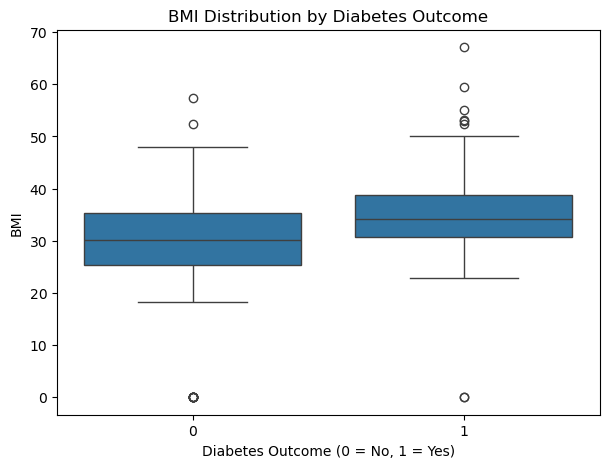

In [22]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x="Outcome",
    y="BMI",
    data=df
)

plt.xlabel("Diabetes Outcome (0 = No, 1 = Yes)")
plt.ylabel("BMI")
plt.title("BMI Distribution by Diabetes Outcome")

plt.show()

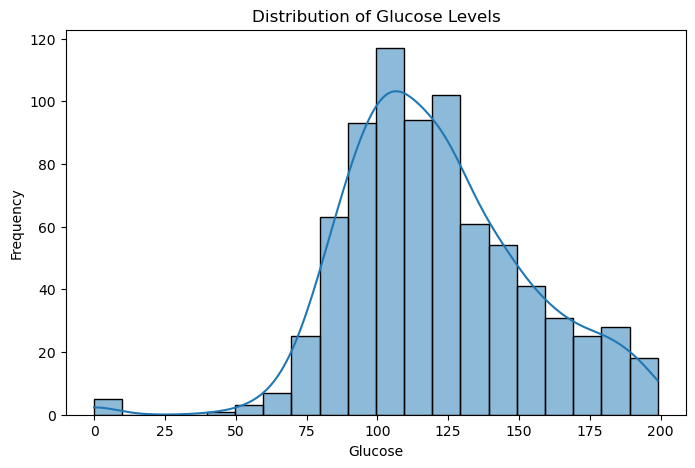

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Glucose"],
    bins=20,
    kde=True
)

plt.xlabel("Glucose")
plt.ylabel("Frequency")
plt.title("Distribution of Glucose Levels")

plt.show()

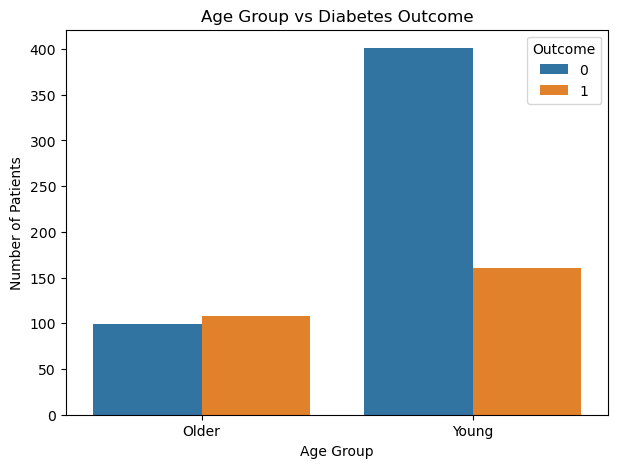

In [24]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="AgeGroup",
    hue="Outcome",
    data=df
)

plt.xlabel("Age Group")
plt.ylabel("Number of Patients")
plt.title("Age Group vs Diabetes Outcome")

plt.show()